In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
from wordcloud import WordCloud

In [317]:
df = pd.read_csv(r"D:\PyCharm\ML Projects\Churn Prediction\Dataset\spam.csv", encoding="latin1")

In [318]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [319]:
df.shape

(5572, 5)

In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


# Data Cleaning

In [321]:
new_df = df.iloc[:, :2]

In [322]:
new_df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [323]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [324]:
new_df.rename(columns = {
    'v1':"target",
    'v2':"text"
}, inplace=True)

C:\Users\AAYUSH NAITHANI\AppData\Local\Temp\ipykernel_7260\510603066.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.rename(columns = {


In [325]:
new_df.columns

Index(['target', 'text'], dtype='object')

In [326]:
le = LabelEncoder()
new_df["target"] = le.fit_transform(new_df["target"])
new_df.head()

C:\Users\AAYUSH NAITHANI\AppData\Local\Temp\ipykernel_7260\401849693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["target"] = le.fit_transform(new_df["target"])


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [327]:
new_df.duplicated().sum()

np.int64(403)

In [328]:
new_df = new_df.drop_duplicates(keep="first")

In [329]:
new_df.reset_index(drop=True, inplace=True)

In [330]:
new_df.shape

(5169, 2)

# EDA

In [331]:
new_df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

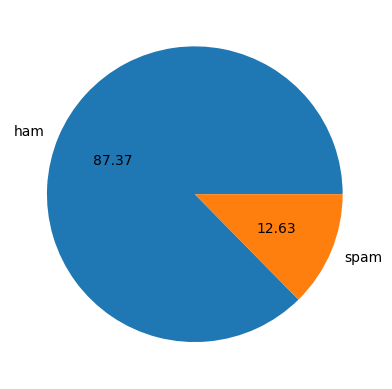

In [332]:
plt.pie(new_df["target"].value_counts(), labels=["ham", "spam"], autopct="%.2f")
plt.show()

In [333]:
new_df["num_char"] = new_df["text"].apply(len)

C:\Users\AAYUSH NAITHANI\AppData\Local\Temp\ipykernel_7260\1368303305.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["num_char"] = new_df["text"].apply(len)


In [334]:
new_df.head()

,target,text,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [335]:
new_df["text"].apply(lambda x: nltk.word_tokenize(x)).apply(len)

0       24
1        8
2       37
3       13
4       15
        ..
5164    35
5165     9
5166    15
5167    27
5168     7
Name: text, Length: 5169, dtype: int64

In [336]:
new_df["num_words"] = new_df["text"].apply(lambda x: len(nltk.word_tokenize(x)))

C:\Users\AAYUSH NAITHANI\AppData\Local\Temp\ipykernel_7260\2982188314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["num_words"] = new_df["text"].apply(lambda x: len(nltk.word_tokenize(x)))


In [337]:
new_df.head()

,target,text,num_char,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [338]:
new_df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

0       2
1       2
2       2
3       1
4       1
       ..
5164    4
5165    1
5166    2
5167    1
5168    2
Name: text, Length: 5169, dtype: int64

In [339]:
new_df["num_sentences"] = new_df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))

C:\Users\AAYUSH NAITHANI\AppData\Local\Temp\ipykernel_7260\2939930247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["num_sentences"] = new_df["text"].apply(lambda x: len(nltk.sent_tokenize(x)))


In [340]:
new_df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [341]:
new_df[["num_char", "num_words", "num_sentences"]].describe()

,num_char,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [342]:
new_df[new_df["target"]==0][["num_char", "num_words", "num_sentences"]].describe() # for HAM only

,num_char,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [343]:
new_df[new_df["target"]==1][["num_char", "num_words", "num_sentences"]].describe() # for SPAM only

,num_char,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_char', ylabel='Count'>

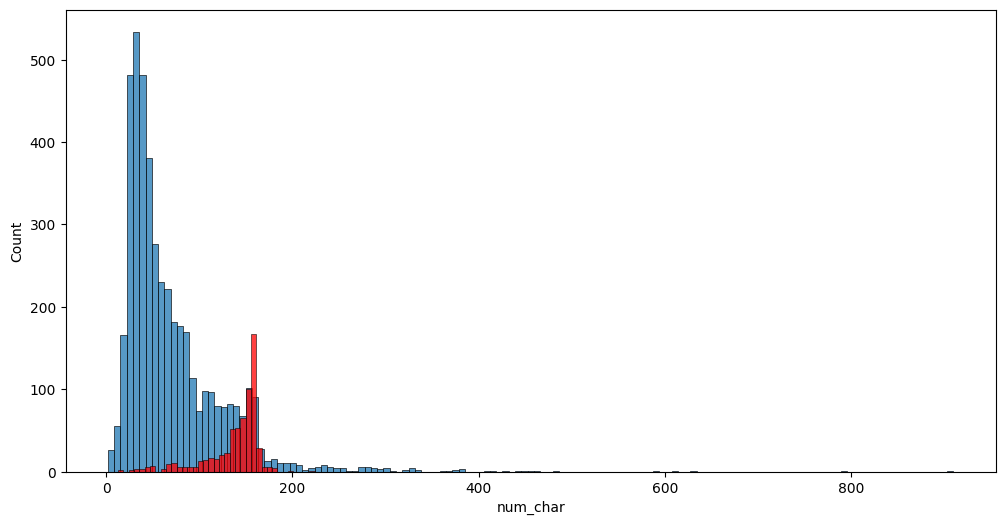

In [344]:
plt.figure(figsize=(12,6))
sns.histplot(new_df[new_df["target"]==0]["num_char"])
sns.histplot(new_df[new_df["target"]==1]["num_char"], color="red")

<Axes: xlabel='num_char'>

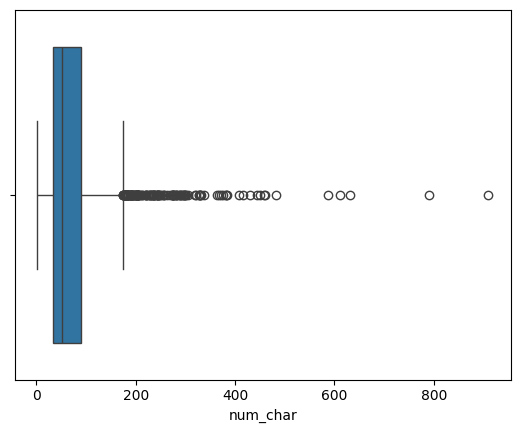

In [345]:
sns.boxplot(x=new_df[new_df["target"]==0]["num_char"])

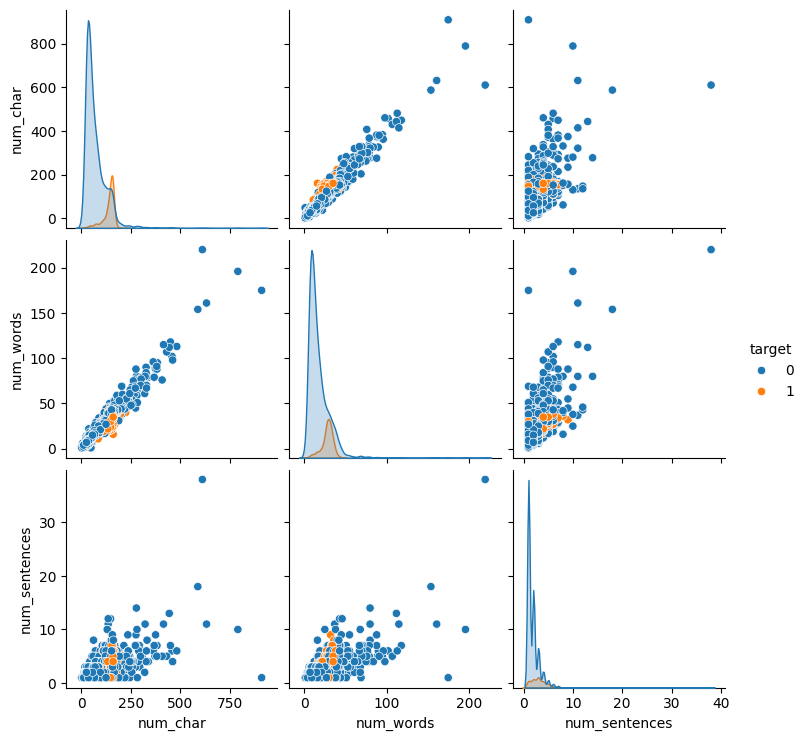

In [346]:
sns.pairplot(new_df, hue="target")

<Axes: >

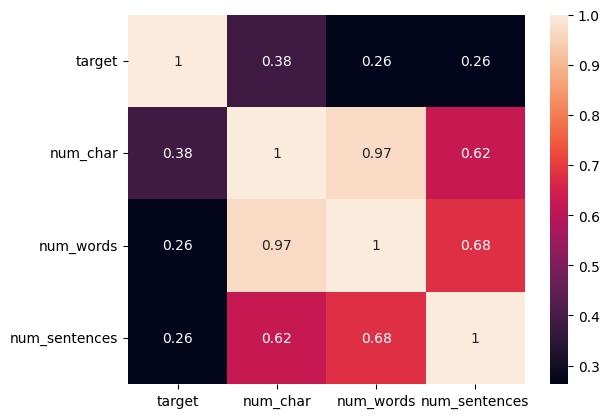

In [347]:
sns.heatmap(new_df.corr(numeric_only=True), annot=True)

# Data Preprocessing
### a. lower case
### b. Tokenization
### c. Removing Special Char
### d. Removing stop words and punctuation
### e. Stemming

In [359]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()

    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

In [362]:
new_df["text"] = new_df["text"].apply(transform_text)

C:\Users\AAYUSH NAITHANI\AppData\Local\Temp\ipykernel_7260\330937591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["text"] = new_df["text"].apply(transform_text)


In [264]:
# for i in range(new_df.shape[0]):
#     new_df["text"][i] = nltk.word_tokenize(new_df["text"][i])

In [364]:
new_df

,target,text,num_char,num_words,num_sentences
0,0,go jurong point crazi avail bugi n great world...,111,24,2
1,0,ok lar joke wif u oni,29,8,2
2,1,free entri 2 wkli comp win fa cup final tkt 21...,155,37,2
3,0,u dun say earli hor u c alreadi say,49,13,1
4,0,nah think goe usf live around though,61,15,1
...,...,...,...,...,...
5164,1,2nd time tri 2 contact u pound prize 2 claim e...,161,35,4
5165,0,b go esplanad fr home,37,9,1
5166,0,piti mood suggest,57,15,2
5167,0,guy bitch act like interest buy someth els nex...,125,27,1


In [368]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color="white")

In [370]:
spam_wc = wc.generate(new_df[new_df["target"]==1]["text"].str.cat(sep=" "))

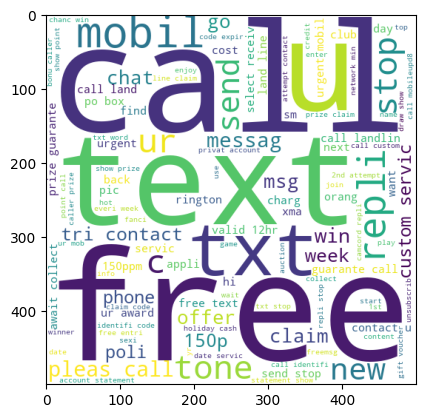

In [372]:
plt.imshow(spam_wc)

In [373]:
ham_wc = wc.generate(new_df[new_df["target"]==0]["text"].str.cat(sep=" "))

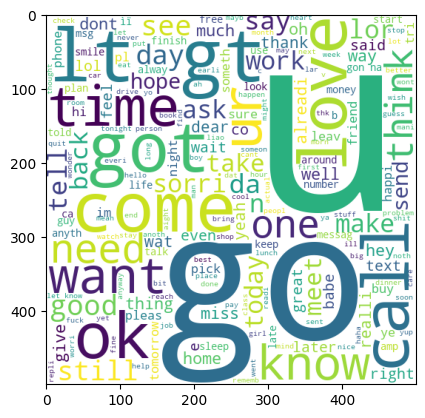

In [375]:
plt.imshow(ham_wc)

In [378]:
new_df.head()

,target,text,num_char,num_words,num_sentences
0,0,go jurong point crazi avail bugi n great world...,111,24,2
1,0,ok lar joke wif u oni,29,8,2
2,1,free entri 2 wkli comp win fa cup final tkt 21...,155,37,2
3,0,u dun say earli hor u c alreadi say,49,13,1
4,0,nah think goe usf live around though,61,15,1


# Vectorization of Words

In [397]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# cv = CountVectorizer()
tv = TfidfVectorizer()
# X = cv.fit_transform(new_df["text"]).toarray()
X = tv.fit_transform(new_df["text"]).toarray()

In [398]:
X.shape

(5169, 6708)

In [399]:
y = new_df["target"].values

In [400]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [401]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [402]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
print("Gaussian")
print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print("Confusion:")
print(confusion_matrix(y_test, y_pred))
print("Precision:")
print(precision_score(y_test, y_pred))
print("\n")
print("Multinomial")
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print("Confusion:")
print(confusion_matrix(y_test, y_pred))
print("Precision:")
print(precision_score(y_test, y_pred))
print("\n")
print("Bernoulli")
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print("Confusion:")
print(confusion_matrix(y_test, y_pred))
print("Precision:")
print(precision_score(y_test, y_pred))

Gaussian
Accuracy:
0.8762088974854932
Confusion:
[[793 103]
 [ 25 113]]
Precision:
0.5231481481481481


Multinomial
Accuracy:
0.9593810444874274
Confusion:
[[896   0]
 [ 42  96]]
Precision:
1.0


Bernoulli
Accuracy:
0.9700193423597679
Confusion:
[[893   3]
 [ 28 110]]
Precision:
0.9734513274336283


In [403]:
# tv-->multinomial

In [404]:
import pickle
pickle.dump(tv, open("Model/Vectorizer.pkl", "wb"))
pickle.dump(mnb, open("Model/model.pkl", "wb"))